In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

In [2]:
df = pd.read_csv(r'lixo - Consolidado.csv')
df = df.drop(columns=['Unnamed: 6', 'Resíduo é essencial']).rename(columns={'Unnamed: 5': 'Essencialidade', 'O que ocorre com o resíduo depois': 'Destino'})

In [3]:
df.head()

,Aluno,Tipo do resíduo,Material,Destino,Essencialidade
0,Aline,Embalagem de Detergente,Plástico,Reciclagem,Sim
1,Aline,Tubo de Papel Higiênico,Papelão,Reciclagem,Sim
2,Aline,Embalagem de Chocolate,Papel,Reciclagem,Sim
3,Aline,Bandeija de Carne,Isopor,Aterro ou reciclagem,Sim
4,Aline,Bandeija de Carne,Isopor,Aterro ou reciclagem,Sim


In [4]:
df_filtrado = df[~(df['Material'].isin(['orgânico', 'Orgânico']))]

In [5]:
df['Material'].unique()

array(['Plástico', 'Papelão', 'Papel', 'Isopor', 'Algodão', 'Metal',
       'Argila e minerais', 'Papelão + Plástico',
       'Papel, Plástico e Alumínio', 'Plástico + Alumínio', 'Vidro',
       'Orgânico', 'Alumínio', 'Papel + plástico', 'Tecido',
       'Papel + orgânico', 'Madeira', 'Papel + plástico + alumínio',
       'Papel / Isopor', 'Papel / Plástico', 'Plástico, Alumínio',
       'Plástico + algodão', 'Poliuretano e Poliéster', 'Fibras mistas',
       'vidro', 'Metal + Plástico'], dtype=object)

In [6]:
df_filtrado.shape

(184, 5)

In [7]:
CORES_RESIDUOS = {
    'papel': '#2196F3',
    'papelão': '#2196F3',
    'papelao': '#2196F3',

    'plástico': '#F44336',
    'plastico': '#F44336',

    'vidro': '#4CAF50',

    'metal': '#FFC107',

    'madeira': '#212121',

    'perigoso': '#FF9800',
    'perigosos': '#FF9800',

    'saúde': '#FFFFFF',
    'saude': '#FFFFFF',

    'radioativo': '#9C27B0',
    'radioativos': '#9C27B0',

    'orgânico': '#795548',
    'organico': '#795548',
    'orgânicos': '#795548',
    'organicos': '#795548',

    'não reciclável': '#9E9E9E',
    'nao reciclavel': '#9E9E9E',
    'rejeito': '#9E9E9E',
    
    'sim' : '#4CAF50',
    'não' : '#F44336',
    
    'reciclagem' : '#4CAF50',
    'aterro ou reciclagem' : '#FFC107',
    'aterro' : '#F44336'
}

In [8]:
def separar_materiais(df, coluna='Material'):
    df = df.copy()

    df[coluna] = (
        df[coluna]
        .astype('string')
        .str.split(r'\s*\+\s*')
    )

    df = df.explode(coluna)

    df = df[~(df[coluna].isin(['orgânico', 'Orgânico']))]
    
    df[coluna] = df[coluna].str.strip()

    return df

In [9]:
def donut_plot(df, coluna):

    counts = df[coluna].value_counts()

    cores = [
        CORES_RESIDUOS.get(str(valor).lower(), '#BDBDBD')
        for valor in counts.index
    ]

    fig, ax = plt.subplots(figsize=(9, 6))

    wedges, _, autotexts = ax.pie(
        counts,
        colors=cores,
        startangle=90,
        counterclock=False,
        autopct=lambda pct: f'{pct:.1f}%' if pct >= 3 else '',
        pctdistance=0.78,
        wedgeprops={
            'width': 0.40,
            'edgecolor': 'none'
        },
        textprops={
            'fontsize': 14,
            'fontweight': 'bold',
            'color': 'white'
        }
    )

    # Legenda
    ax.legend(
        wedges,
        [
            f'{valor} ({count})'
            for valor, count in counts.items()
        ],
        title=coluna,
        title_fontsize=14,
        fontsize=12,
        loc='center left',
        bbox_to_anchor=(0.98, 0.5),
        frameon=False,
        labelspacing=0.7,
        handlelength=1.1,
        handletextpad=0.5,
        borderaxespad=0
    )

    # Título
    ax.set_title(
        f'Distribuição de {coluna}',
        fontsize=18,
        fontweight='bold',
        pad=8
    )

    ax.set_aspect('equal')
    ax.axis('off')

    # Reduz o espaço externo
    plt.subplots_adjust(
        left=0.02,
        right=0.92,
        top=0.88,
        bottom=0.02
    )

    return fig, ax


In [10]:
def uppercase_df(df):
   df = df.map(
    lambda x: x.title() if isinstance(x, str) else x
    )
   return df

In [11]:
up_df = uppercase_df(df_filtrado)
df_material = separar_materiais(up_df, 'Material')

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Distribuição de Essencialidade'}>)

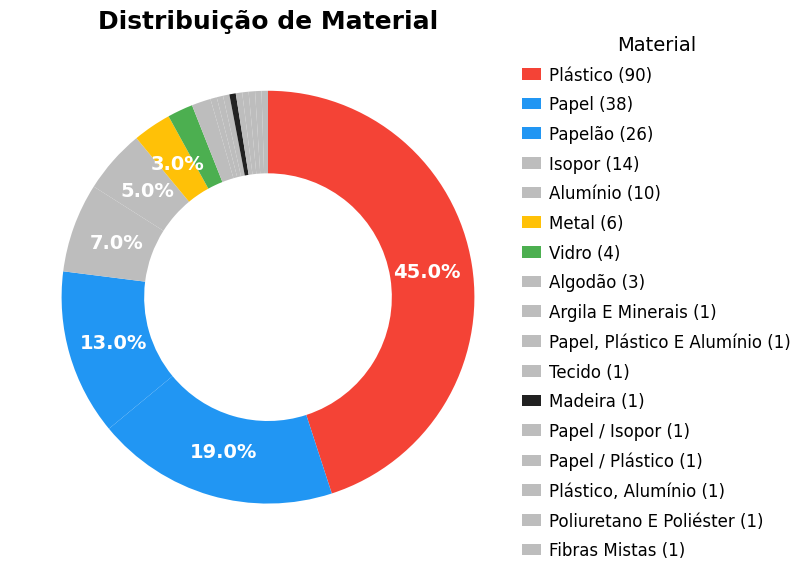

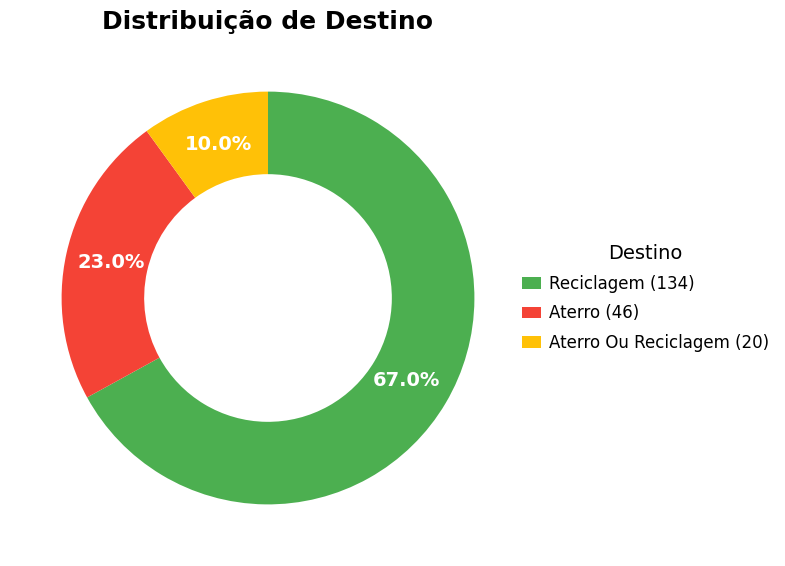

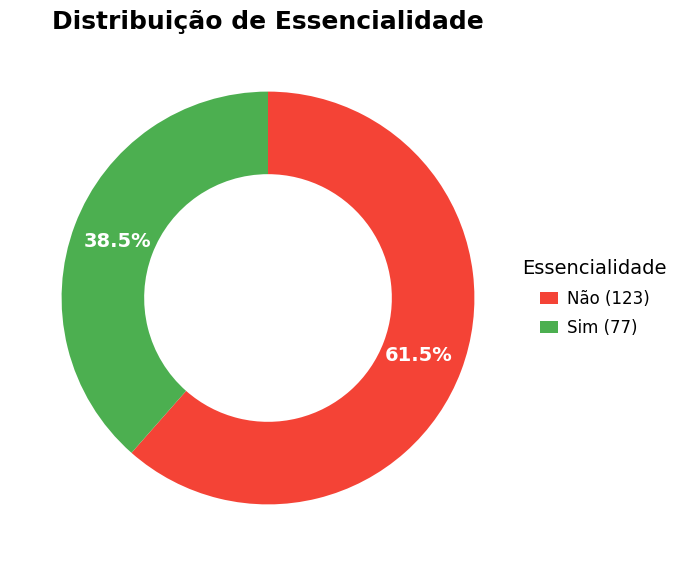

In [12]:
donut_plot(df_material, 'Material')
donut_plot(df_material, 'Destino')
donut_plot(df_material, 'Essencialidade')

In [13]:
alunos = ['Aline', 'Dani', 'Derek', 'Gi', 'Gui', 'João']

In [14]:
from pathlib import Path


for aluno in alunos:
    print(f'Analisando dados do aluno: {aluno}')

    
    pasta = Path('grafico') / str(aluno)
    pasta.mkdir(parents=True, exist_ok=True)

    aluno_df = df_material[df_material['Aluno'] == aluno]

    fig1, ax1 = donut_plot(aluno_df, 'Material')
    fig2, ax2 = donut_plot(aluno_df, 'Destino')
    fig3, ax3 = donut_plot(aluno_df, 'Essencialidade')

    fig1.savefig(pasta / f'{aluno}_material.png', dpi=300, bbox_inches='tight')
    fig2.savefig(pasta / f'{aluno}_destino_residuo.png', dpi=300, bbox_inches='tight')
    fig3.savefig(pasta / f'{aluno}_essencialidade.png', dpi=300, bbox_inches='tight')

    plt.close(fig1)
    plt.close(fig2)
    plt.close(fig3)

Analisando dados do aluno: Aline
Analisando dados do aluno: Dani
Analisando dados do aluno: Derek
Analisando dados do aluno: Gi
Analisando dados do aluno: Gui
Analisando dados do aluno: João


In [15]:
verde_escuro = '#2E7D32'
verde_claro = '#A5D6A7'

(<Figure size 1000x700 with 2 Axes>,
 (<Axes: title={'center': 'Resíduos e taxa de reciclagem por aluno'}, ylabel='Quantidade de resíduos'>,
  <Axes: >))

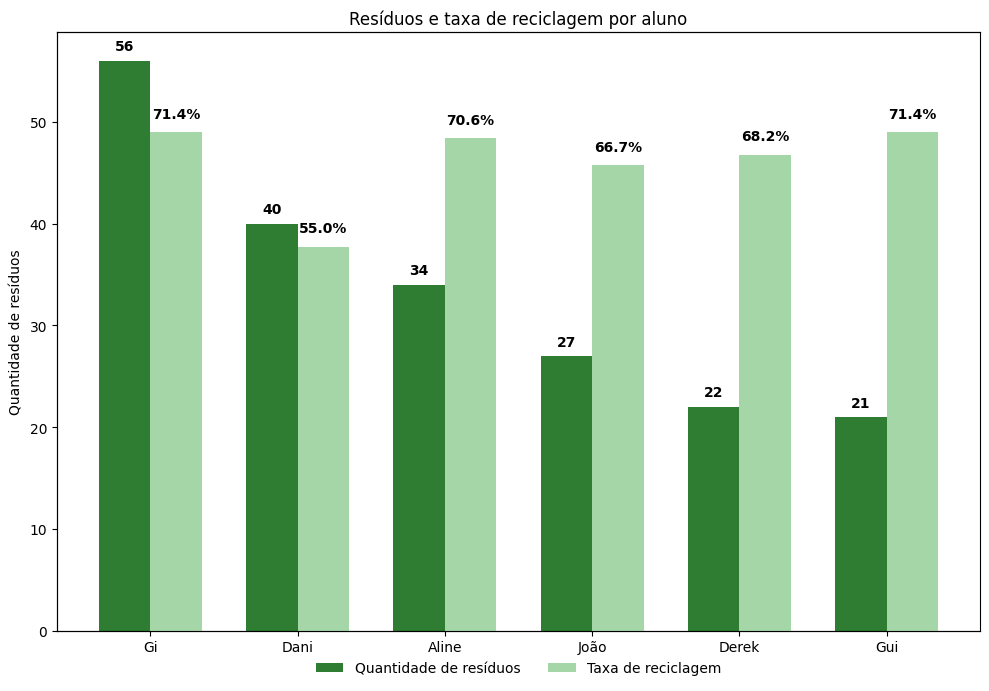

In [16]:
def residuos_por_aluno(df):
    contagem = df['Aluno'].value_counts()

    reciclados = (
        df['Destino'] == 'Reciclagem'
    ).groupby(df['Aluno']).mean() * 100

    fig, ax1 = plt.subplots(figsize=(10, 7))

    alunos = contagem.index
    x = np.arange(len(alunos))
    largura = 0.35

    # Eixo principal: quantidade de resíduos
    ax1.bar(
        x - largura / 2,
        contagem.values,
        largura,
        color='#2E7D32',
        label='Quantidade de resíduos'
    )

    # Eixo secundário: taxa de reciclagem
    ax2 = ax1.twinx()

    ax2.bar(
        x + largura / 2,
        reciclados.reindex(alunos),
        largura,
        color='#A5D6A7',
        label='Taxa de reciclagem'
    )

    # Esconde o eixo secundário
    ax2.set_yticks([])
    ax2.spines['right'].set_visible(False)

    ax1.set_xticks(x)
    ax1.set_xticklabels(alunos)
    ax1.set_ylabel('Quantidade de resíduos')
    ax1.set_title('Resíduos e taxa de reciclagem por aluno')

    # Valores nas barras
    for i, valor in enumerate(contagem.values):
        ax1.text(
            i - largura / 2,
            valor + 1,
            str(valor),
            ha='center',
            fontweight='bold'
        )

    for i, valor in enumerate(reciclados.reindex(alunos)):
        ax2.text(
            i + largura / 2,
            valor + 2,
            f'{valor:.1f}%',
            ha='center',
            fontweight='bold'
        )

    # Legenda combinada
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.03),
        ncol=2,
        frameon=False
    )

    ax2.margins(y=0.2)
    plt.tight_layout()

    return fig, (ax1, ax2)

residuos_por_aluno(df_material)

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Top 15 tipos de resíduos mais frequentes'}, xlabel='Quantidade'>)

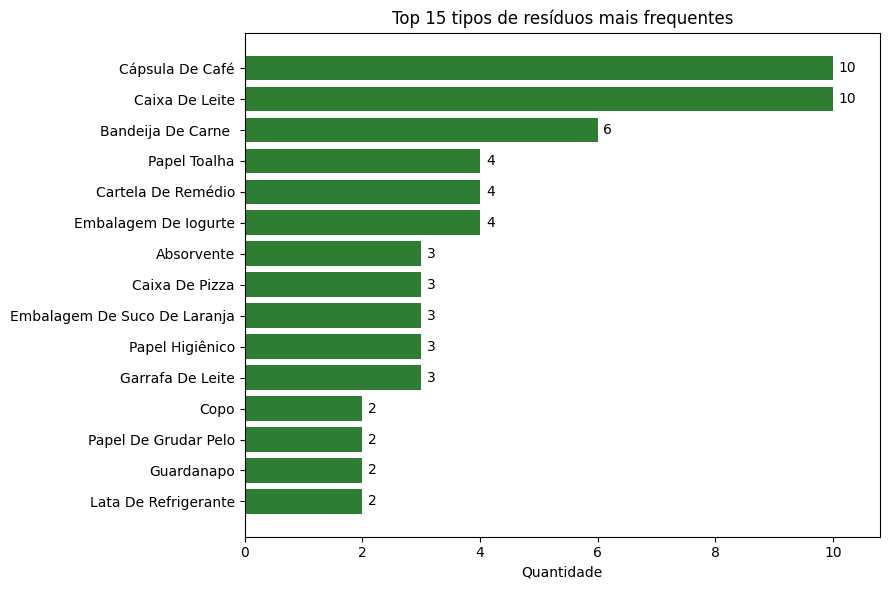

In [17]:
def tipos_residuos_plot(df, n=15):
    tipos = (
        df['Tipo do resíduo']
        .value_counts()
        .head(n)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.barh(
        tipos.index,
        tipos.values,
        color=verde_escuro
    )

    ax.set_xlabel('Quantidade')
    ax.set_title(f'Top {n} tipos de resíduos mais frequentes')

    for i, valor in enumerate(tipos.values):
        ax.text(
            valor + 0.1,
            i,
            str(valor),
            va='center'
        )

    ax.margins(x=0.08)

    plt.tight_layout()

    return fig, ax

tipos_residuos_plot(df_material, n=15)

<Axes: title={'center': 'Destino dos 6 materiais mais frequentes'}, xlabel='Material', ylabel='Quantidade'>

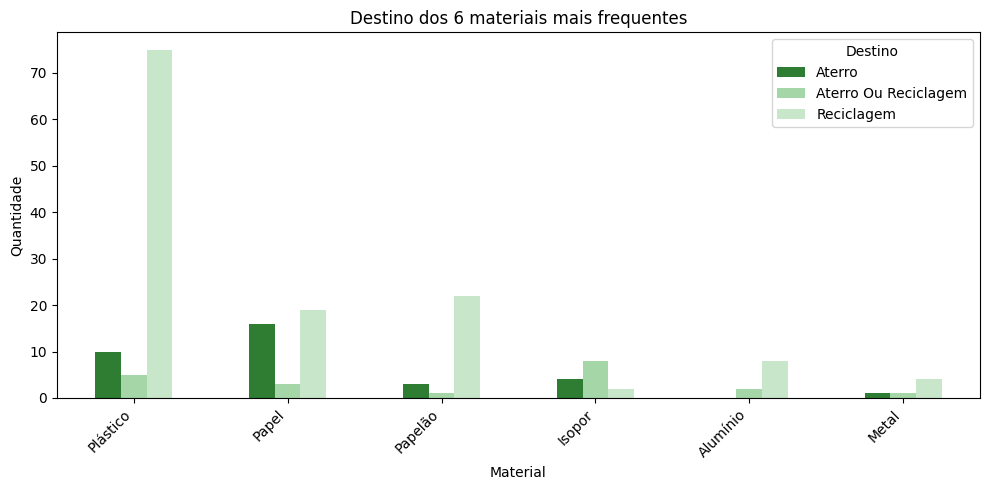

In [18]:
def material_destino_plot(df, n=10):
    material_destino = pd.crosstab(
        df['Material'],
        df['Destino']
    )

    material_destino = material_destino.loc[
        material_destino.sum(axis=1)
        .nlargest(n)
        .index
    ]

    ax = material_destino.plot(
        kind='bar',
        figsize=(10, 5),
        color=[
            verde_escuro,
            verde_claro,
            '#C8E6C9'
        ]
    )

    ax.set_title(f'Destino dos {n} materiais mais frequentes')
    ax.set_xlabel('Material')
    ax.set_ylabel('Quantidade')

    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Destino')

    plt.tight_layout()

    return ax

material_destino_plot(df_material, n=6)